# Abstract figure: structure tensor vs. nematic tensor

The ring image at the medium degradation level (saturation ratio $\rho_{\mathrm{sat}}=0.6$, Gaussian noise $\sigma_{\mathrm{noise}}=0.015$, ramp slope $\beta_{\mathrm{ramp}}=0.02$/px), the reference orientation of the clean rings, the orientation histograms of the three estimators in the evaluation mask, and the estimated orientation fields as HSB maps (hue = orientation, saturation = confidence, brightness = energy), all with the same Gaussian window $\sigma_{\mathrm{agg}}=7$ px.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


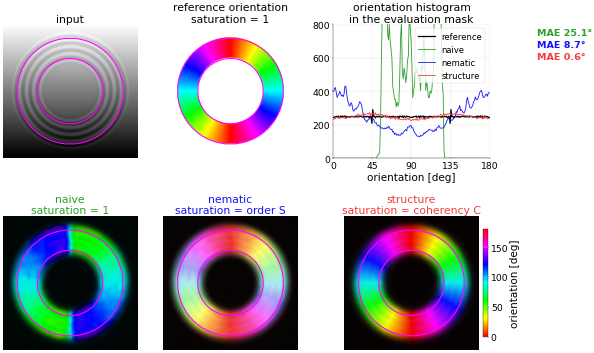

In [ ]:
%load_ext autoreload
%autoreload 2
import importlib, ring_experiment_lib
importlib.reload(ring_experiment_lib)
from ring_experiment_lib import *

# ============================================================
# Figure settings: edit here to change the rendering
# ============================================================
IMAGE = dict(saturation_ratio=0.6,          # ρ_sat, ratio of saturated pixels (medium level of the experiment notebook)
             noise_std=0.015,               # σ_noise, std of the Gaussian noise
             ramp_slope=0.02,               # β_ramp, slope of the ramp [intensity / px]
             shot_lambda=0.0)               # λ_shot, intensity of one photon (0: no shot noise)
FONTSIZE = {'base': 24, 'title': 26, 'label': 25, 'tick': 22, 'legend': 20, 'mae': 23}
PAD = {'w_pad': 0.00, 'h_pad': 0.2}          # space between panels [inches]
FIGSIZE = (20, 12)                           # 2 rows x 3 columns
HISTOGRAM_YLIM = (0, 800)                    # y-range of the orientation histogram [pixels per bin]; flat reference ≈ 247
SHOW_MAE = True                              # MAE of each estimator in the histogram panel
LEGEND = dict(loc='upper right', frameon=True)
REFERENCE_MASK_ONLY = True                   # reference orientation shown only in the evaluation annulus
COLORBAR_INSET = [1.03, 0.1, 0.04, 0.8]      # colorbar next to the structure map: [x0, y0, width, height], axes fraction
TITLES = {'input': 'input',         # {label} is replaced by the degradation values
          'reference': 'reference orientation\nsaturation = 1',
          'histogram': 'orientation histogram\nin the evaluation mask',
          'naive': 'naive\nsaturation = 1',
          'nematic': 'nematic\nsaturation = order S',
          'structure': 'structure\nsaturation = coherency C'}

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': FONTSIZE['base'], 'axes.titlesize': FONTSIZE['title'],
    'axes.labelsize': FONTSIZE['label'], 'xtick.labelsize': FONTSIZE['tick'], 'ytick.labelsize': FONTSIZE['tick'],
    'legend.fontsize': FONTSIZE['legend'], 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#dddddd', 'grid.linewidth': 0.8})


def plot_orientation_histogram(ax, analysis, title, estimators=ESTIMATOR_NAMES, show_mae=True):
    """Reference and estimated orientation histograms in the evaluation mask, with the MAE of each estimator."""
    histogram_line(ax, analysis['reference'], color=COLORS['reference'], lw=LINEWIDTHS['reference'], label='reference')
    for name in estimators:
        histogram_line(ax, analysis['angles'][name], color=COLORS[name], lw=LINEWIDTHS[name], label=name)
    if show_mae:
        for k, name in enumerate(estimators):
            ax.text(1.3, 0.97 - 0.09 * k, f'MAE {analysis["mae"][name]:.1f}°', transform=ax.transAxes,
                    ha='left', va='top', color=COLORS[name], fontsize=FONTSIZE['mae'], fontweight='bold')
    ax.set_xlim(0, 180)
    ax.set_ylim(*HISTOGRAM_YLIM)
    ax.set_xticks(np.arange(0, 181, 45))
    ax.set_xlabel('orientation [deg]')
    #ax.set_ylabel(f'pixels per {ANGLE_BIN:g}° bin')
    ax.set_title(title)


# ============================================================
# Figure
# ============================================================
image = make_ring_image(**IMAGE)
analysis = analyze(image)

fig, axes = plt.subplots(2, 3, figsize=FIGSIZE, constrained_layout=True)
pad_layout(fig, **PAD)
show_image(axes[0, 0], image['image'], TITLES['input'].format(label=degradation_label(image)))
draw_mask_outline(axes[0, 0], image['mask'])
plot_reference_map(axes[0, 1], image, TITLES['reference'], mask_only=REFERENCE_MASK_ONLY)
plot_orientation_histogram(axes[0, 2], analysis, TITLES['histogram'], show_mae=SHOW_MAE)
axes[0, 2].legend(**LEGEND)
plot_hsb_maps(axes[1], image, analysis, titles=TITLES)
orientation_colorbar(fig, axes[1, 2], inset=COLORBAR_INSET)
fig.savefig(RESULTS / 'abstract_figure.png', dpi=150, bbox_inches='tight')
plt.show()